### Import Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Load Data

In [2]:
file_path = '/Users/baselhussein/Projects/impossible_goals/brick_wall/data/cluster_features_quit.csv'
# id_list = '/Users/baselhussein/Projects/impossible_goals/agg/data/ids_evaluation.csv'

In [3]:
df_import = pd.read_csv(file_path)
# df_ids = pd.read_csv(id_list)

In [4]:
# df = pd.merge(df_import, df_ids)
df = df_import

In [5]:
df

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
0,15,5,18,95.593400,13.434,72,303,715.950,12.800000
1,49,3,3,22.594667,1.850,19,40,101.267,6.333333
2,101,2,0,11.183500,21.767,8,36,76.950,3.500000
3,157,4,7,7.999500,8.000,23,73,64.833,5.250000
4,159,5,29,59.333800,18.333,121,811,508.533,12.400000
5,160,7,24,185.694857,24.966,63,407,1915.750,8.000000
6,178,4,3,33.883000,20.133,24,89,183.800,5.500000
7,187,4,18,153.266750,82.550,131,491,852.600,15.500000
8,234,6,15,47.941833,14.650,32,337,428.100,5.000000
9,250,7,10,39.676286,31.017,70,353,603.234,9.000000


In [6]:
df.describe()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,149.000000,4.700000,12.700000,65.716759,23.670000,56.300000,294.000000,545.101700,8.328333
std,74.726167,1.636392,9.684466,60.704399,22.298294,43.091763,246.356562,557.591979,4.005722
min,15.000000,2.000000,0.000000,7.999500,1.850000,8.000000,36.000000,64.833000,3.500000
25%,115.000000,4.000000,4.000000,25.416750,13.738000,23.250000,77.000000,121.900250,5.312500
50%,159.500000,4.500000,12.500000,43.809060,19.233000,47.500000,320.000000,468.316500,7.166667
75%,184.750000,5.750000,18.000000,86.528500,24.166250,71.500000,393.500000,687.771000,11.550000
max,250.000000,7.000000,29.000000,185.694857,82.550000,131.000000,811.000000,1915.750000,15.500000


### Preprocessing

#### Drop Outliers

In [7]:
def remove_outliers(df, threshold=3):
    """
    Remove outliers that are more than `threshold` standard deviations from the mean.
    """
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        lower_bound, upper_bound = mean - threshold * std, mean + threshold * std
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

In [8]:
data = remove_outliers(df)

In [9]:
data.describe()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,149.000000,4.700000,12.700000,65.716759,23.670000,56.300000,294.000000,545.101700,8.328333
std,74.726167,1.636392,9.684466,60.704399,22.298294,43.091763,246.356562,557.591979,4.005722
min,15.000000,2.000000,0.000000,7.999500,1.850000,8.000000,36.000000,64.833000,3.500000
25%,115.000000,4.000000,4.000000,25.416750,13.738000,23.250000,77.000000,121.900250,5.312500
50%,159.500000,4.500000,12.500000,43.809060,19.233000,47.500000,320.000000,468.316500,7.166667
75%,184.750000,5.750000,18.000000,86.528500,24.166250,71.500000,393.500000,687.771000,11.550000
max,250.000000,7.000000,29.000000,185.694857,82.550000,131.000000,811.000000,1915.750000,15.500000


#### Explore Data Relationships

In [10]:
df_numeric = data.drop(columns=['ID'])

In [11]:
correlation_matrix = df_numeric.corr()
correlation_matrix

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
unique_goals,1.000000,0.610679,0.471961,0.054635,0.357528,0.523121,0.677885,0.246944
total_returns,0.610679,1.000000,0.690252,0.259494,0.797388,0.918571,0.689186,0.688984
seconds_per_goal,0.471961,0.690252,1.000000,0.580296,0.623026,0.518425,0.922953,0.619063
seconds_to_first_goal_switch,0.054635,0.259494,0.580296,1.000000,0.666374,0.387570,0.350221,0.622297
impasses,0.357528,0.797388,0.623026,0.666374,1.000000,0.886968,0.476022,0.938983
input_count_exploring,0.523121,0.918571,0.518425,0.387570,0.886968,1.000000,0.493582,0.723984
time_in_level_seconds,0.677885,0.689186,0.922953,0.350221,0.476022,0.493582,1.000000,0.420104
avg_impasse_per_goal,0.246944,0.688984,0.619063,0.622297,0.938983,0.723984,0.420104,1.000000


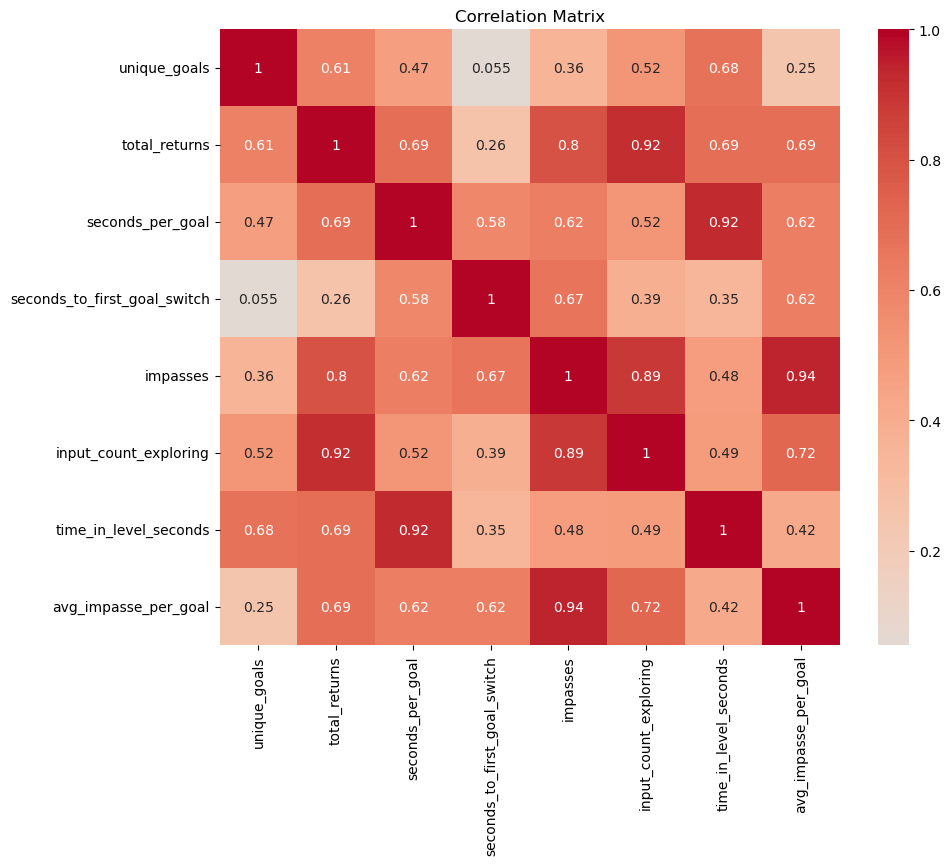

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Keep Relevant Features

In [13]:
data_numeric = df_numeric.drop(columns=['input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_numeric

,total_returns,seconds_to_first_goal_switch
0,18,13.434
1,3,1.850
2,0,21.767
3,7,8.000
4,29,18.333
5,24,24.966
6,3,20.133
7,18,82.550
8,15,14.650
9,10,31.017


In [47]:
# data_numeric = remove_outliers(data_numeric)
# data_numeric

In [48]:
data_numeric.describe()

,total_returns,seconds_to_first_goal_switch
count,10.000000,10.000000
mean,12.700000,23.670000
std,9.684466,22.298294
min,0.000000,1.850000
25%,4.000000,13.738000
50%,12.500000,19.233000
75%,18.000000,24.166250
max,29.000000,82.550000


#### Normalize Data

In [49]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

### Model

#### Hierarchical Clustering

In [50]:
linked = linkage(data_scaled, method='ward')

#### Visualize Dendrogram

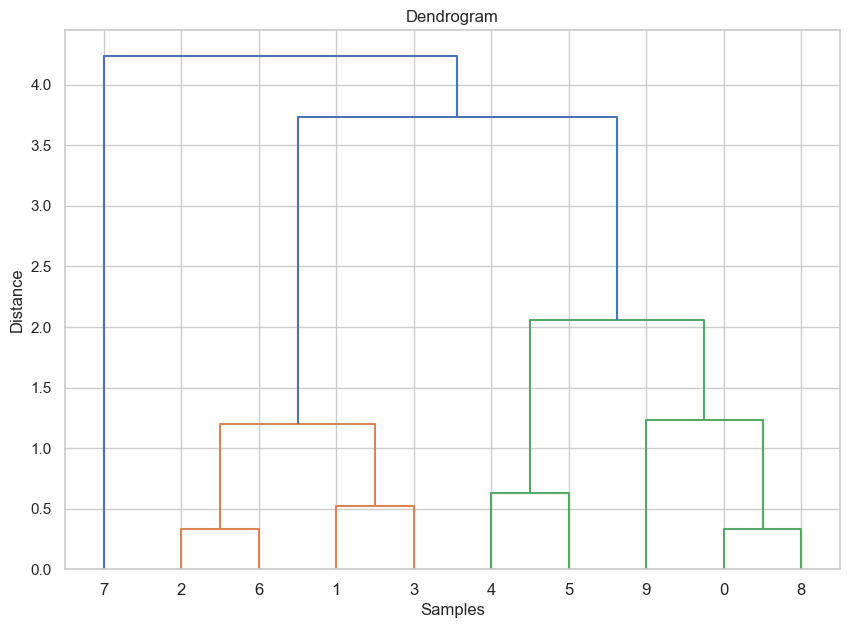

In [51]:
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', no_labels=False)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.axhline(y=7, color='r', linestyle='--')  # Check threshold
plt.show()

### Evaluate Threshold for Clusters 

In [56]:
# Function to calculate silhouette score for different thresholds
def evaluate_silhouette(linked, data_scaled, thresholds):
    best_threshold = None
    best_score = -1
    scores = []
    
    for threshold in thresholds:
        labels = fcluster(linked, threshold, criterion='distance')
        score = silhouette_score(data_scaled, labels)
        scores.append((threshold, score))
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score, scores

# Define a range of thresholds to evaluate
thresholds = np.arange(1, 4.5, 0.5)

# Evaluate silhouette score for different thresholds
best_threshold, best_score, scores = evaluate_silhouette(linked, data_scaled, thresholds)

print(f"Best Threshold: {best_threshold}")
print(f"Best Silhouette Score: {best_score}")

# Display scores for each threshold
for threshold, score in scores:
    print(f"Threshold: {threshold}, Silhouette Score: {score}")

Best Threshold: 4.0
Best Silhouette Score: 0.4894275382488423
Threshold: 1.0, Silhouette Score: 0.42970316366592465
Threshold: 1.5, Silhouette Score: 0.37944738218815816
Threshold: 2.0, Silhouette Score: 0.37944738218815816
Threshold: 2.5, Silhouette Score: 0.40316628256868886
Threshold: 3.0, Silhouette Score: 0.40316628256868886
Threshold: 3.5, Silhouette Score: 0.40316628256868886
Threshold: 4.0, Silhouette Score: 0.4894275382488423


### Label Data w/ Clusters @ Threshold

In [57]:
# Form flat clusters using the specified threshold
threshold = 4
clusters = fcluster(linked, t=threshold, criterion='distance')

# Add the cluster labels to the original dataset
data['cluster'] = clusters

# Display the first few rows of the updated dataset
data.head()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal,cluster
0,15,5,18,95.593400,13.434,72,303,715.950,12.800000,1
1,49,3,3,22.594667,1.850,19,40,101.267,6.333333,1
2,101,2,0,11.183500,21.767,8,36,76.950,3.500000,1
3,157,4,7,7.999500,8.000,23,73,64.833,5.250000,1
4,159,5,29,59.333800,18.333,121,811,508.533,12.400000,1


### Clean Data

In [58]:
data_export = data.drop(columns=['input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_export

,ID,total_returns,seconds_to_first_goal_switch,cluster
0,15,18,13.434,1
1,49,3,1.850,1
2,101,0,21.767,1
3,157,7,8.000,1
4,159,29,18.333,1
5,160,24,24.966,1
6,178,3,20.133,1
7,187,18,82.550,2
8,234,15,14.650,1
9,250,10,31.017,1


### Explore Clusters

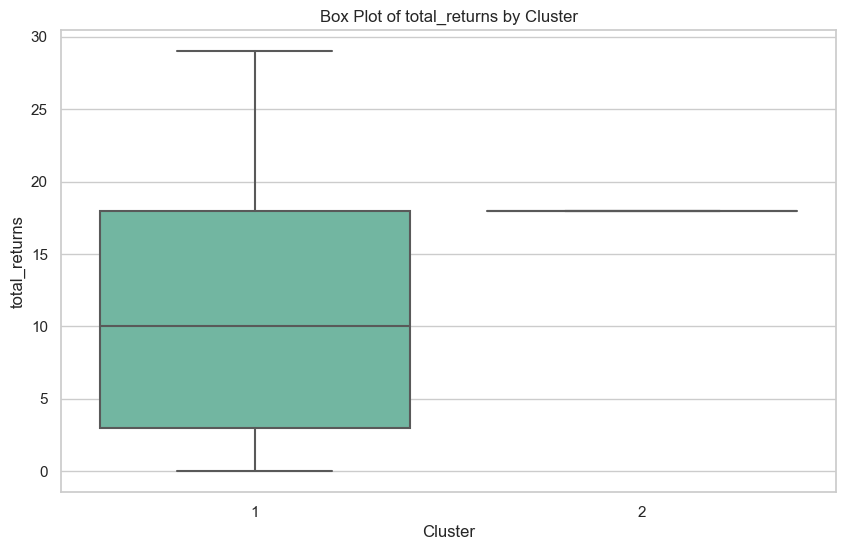

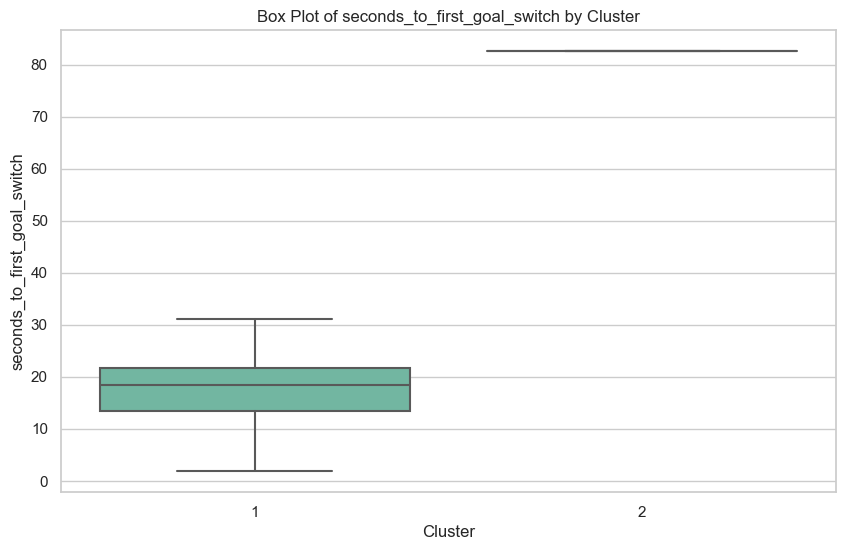

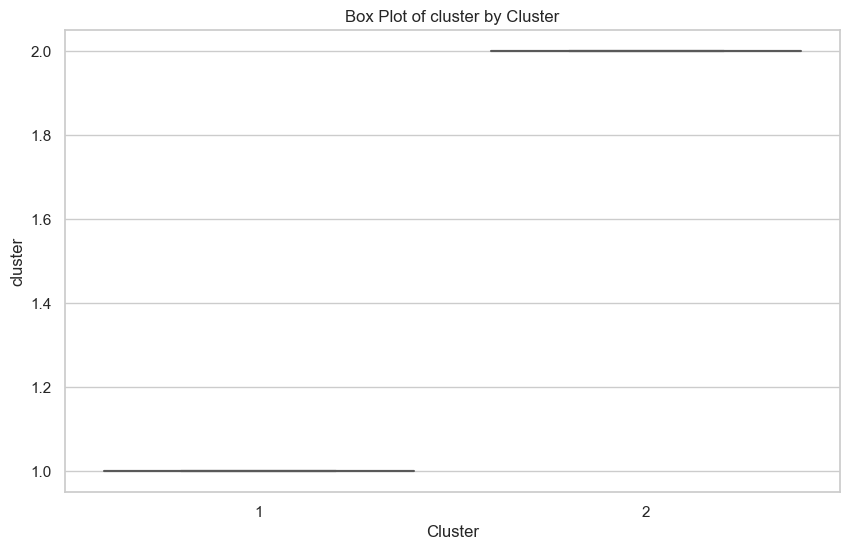

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Function to create box plots for each numeric column grouped by 'Cluster'
def plot_boxplots(data_export, numeric_columns):
    for column in numeric_columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data_export, x='cluster', y=column, palette='Set2')
        plt.title(f'Box Plot of {column} by Cluster')
        plt.xlabel('Cluster')
        plt.ylabel(column)
        plt.show()


# List of numeric columns
numeric_columns = data_export.columns[data_export.dtypes != 'object'].tolist()
numeric_columns.remove('ID')  # Exclude ID as it's not a relevant numeric column for analysis


# Plot box plots
plot_boxplots(data_export, numeric_columns)

In [102]:
# Define the mapping
cluster_mapping = {
    1: 'low-returns_fast-reframe',
    2: 'high-returns_fast-reframe',
    3: 'low-returns_slow-reframe'
    # Add more mappings as needed
}

# Add a new column based on the 'cluster' column
data_export['cluster-category-bw'] = data_export['cluster'].map(cluster_mapping)

In [103]:
# data_export['cluster-category'] = data_export['cluster-category'] + "_bw"

In [104]:
data_export

,ID,total_returns,seconds_to_first_goal_switch,cluster,cluster-category-bw
0,2,2,13.416,1,low-returns_fast-reframe
1,6,0,8.816,1,low-returns_fast-reframe
2,12,11,17.533,3,low-returns_slow-reframe
3,13,3,9.300,1,low-returns_fast-reframe
4,22,0,15.067,1,low-returns_fast-reframe
...,...,...,...,...,...
143,248,4,7.817,1,low-returns_fast-reframe
144,251,3,2.500,1,low-returns_fast-reframe
145,252,15,14.133,2,high-returns_fast-reframe
147,255,20,8.283,2,high-returns_fast-reframe


### Export Data

In [105]:
# data_export.to_csv('/Users/baselhussein/Projects/impossible_goals/agg/data/bw_clusters.csv', index=False)